In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style
sns.set_theme(style="whitegrid")

# Define Paths
base_dir = Path.cwd().parent
processed_data_dir = base_dir / 'data' / 'processed'
models_dir = base_dir / 'models' / 'behavior_encoder'
visuals_dir = base_dir / 'visualizations'

visuals_dir.mkdir(parents=True, exist_ok=True)

print("Environment setup complete.")

Environment setup complete.


In [2]:
print("Loading Master Behavior Dataset...")
df = pd.read_csv(processed_data_dir / 'master_behavior_data.csv')

# WE ONLY TRAIN ON SAFE DATA (Crucial for Zero-day anomaly detection)
safe_df = df[df['label'] == 'Safe']
print(f"Total Safe Traffic Samples extracted: {safe_df.shape[0]}")

# Define the exact features used in the Random Forest model
features = [
    'Max Packet Length', 'Packet Length Variance', 'Avg Bwd Segment Size', 
    'Average Packet Size', 'Bwd Packet Length Max', 'Destination Port', 
    'Packet Length Std', 'Total Length of Bwd Packets', 'Subflow Fwd Bytes', 
    'Bwd Header Length'
]

X_safe = safe_df[features].values

# Load the PRE-TRAINED scaler from the Behavior Model
print("Loading pre-trained StandardScaler...")
scaler_path = models_dir / 'behavior_scaler.pkl'
scaler = joblib.load(scaler_path)

# Transform the safe data using the existing scaler
X_safe_scaled = scaler.transform(X_safe)
print("Data scaling completed.")

Loading Master Behavior Dataset...
Total Safe Traffic Samples extracted: 50000
Loading pre-trained StandardScaler...
Data scaling completed.


In [3]:
print("Building Deep Autoencoder Architecture...")

input_dim = len(features)
input_layer = Input(shape=(input_dim,))

# Encoder (Compression)
encoder = Dense(8, activation='relu')(input_layer)
encoder = Dense(4, activation='relu')(encoder) # Bottleneck

# Decoder (Reconstruction)
decoder = Dense(8, activation='relu')(encoder)
decoder = Dense(input_dim, activation='linear')(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Building Deep Autoencoder Architecture...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 254 (1016.00 B)

 Trainable params: 254 (1016.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
print("Training Deep Autoencoder on Safe Traffic...")

# Implement Early Stopping to prevent overfitting on the safe data
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = autoencoder.fit(
    X_safe_scaled, 
    X_safe_scaled, # In autoencoders, the input is also the target output
    epochs=10, 
    batch_size=256, 
    validation_split=0.2,
    callbacks=[early_stop]
)

print("Training completed.")

Training Deep Autoencoder on Safe Traffic...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7213 - val_loss: 1.2406
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5133 - val_loss: 1.0414
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4269 - val_loss: 0.9208
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3845 - val_loss: 0.8399
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3601 - val_loss: 0.7898
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3419 - val_loss: 0.7533
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3278 - val_loss: 0.7141
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3157 - val_loss: 0.6893
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3061 - val_loss: 0.6687
Epoch 10/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2982 - val_loss: 0.6435
Training completed.


Calculating Reconstruction Error and Anomaly Threshold...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Calculated Anomaly Threshold (99th Percentile): 0.3274


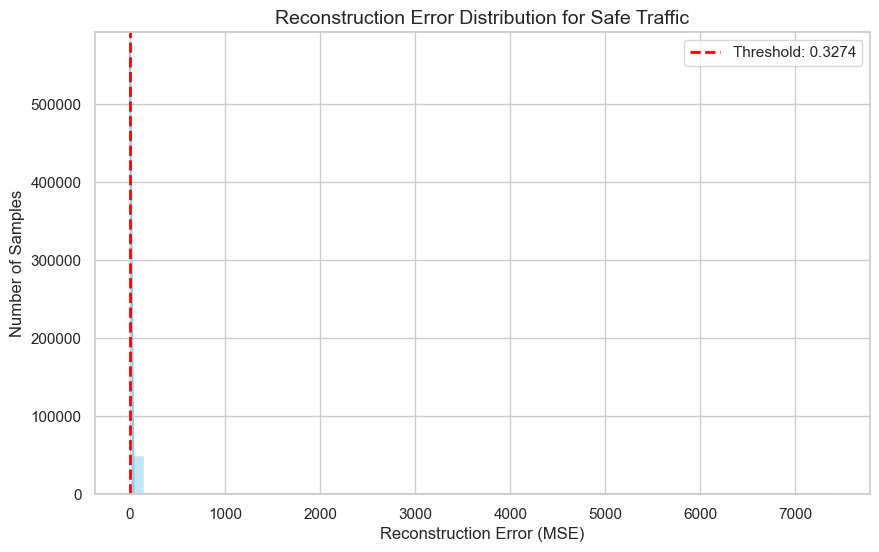

In [5]:
print("Calculating Reconstruction Error and Anomaly Threshold...")

# Predict (reconstruct) the safe data
reconstructions = autoencoder.predict(X_safe_scaled)

# Calculate Mean Squared Error (MSE) for each sample
train_loss = np.mean(np.square(X_safe_scaled - reconstructions), axis=1)

# Set the anomaly threshold at the 99th percentile of the training loss
# This means 99% of normal traffic will fall below this error value.
threshold = np.percentile(train_loss, 99)
print(f"Calculated Anomaly Threshold (99th Percentile): {threshold:.4f}")

# Visualize the distribution of Reconstruction Errors
plt.figure(figsize=(10, 6))
sns.histplot(train_loss, bins=50, kde=True, color='skyblue')
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
plt.title('Reconstruction Error Distribution for Safe Traffic', fontsize=14)
plt.xlabel('Reconstruction Error (MSE)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.legend()

plt.savefig(visuals_dir / '10_autoencoder_reconstruction_error.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
print("Exporting Deep Autoencoder Model...")

model_path = models_dir / 'autoencoder_model.h5'
autoencoder.save(model_path)

print(f"Autoencoder module saved successfully to: {model_path}")
print("PIPELINE COMPLETED.")

Exporting Deep Autoencoder Model...
Autoencoder module saved successfully to: c:\Users\induw\OneDrive\Documents\SENTIO_360_Project\models\behavior_encoder\autoencoder_model.h5
PIPELINE COMPLETED.
